In [1]:
import pandas as pd
import re

In [2]:
train_data = pd.read_csv("/kaggle/input/competitions/playground-series-s6e5/train.csv")
test_df = pd.read_csv(
    "/kaggle/input/competitions/playground-series-s6e5/test.csv")
#train_data = train_data.drop('id', axis = 1)

In [3]:
train_data.columns = [re.sub(r'[^A-Za-z0-9_]+', '_', col).lower() for col in train_data.columns]
test_df.columns = [re.sub(r'[^A-Za-z0-9_]+', '_', col).lower() for col in test_df.columns]

In [4]:
test_df.isnull().sum()

id                        0
driver                    0
compound                  0
race                      0
year                      0
pitstop                   0
lapnumber                 0
stint                     0
tyrelife                  0
position                  0
laptime_s_                0
laptime_delta             0
cumulative_degradation    0
raceprogress              0
position_change           0
dtype: int64

In [5]:
cat_cols = train_data.select_dtypes(include='object').columns
cat_cols

Index(['driver', 'compound', 'race'], dtype='object')

In [6]:
def feature_engineering(train_data):
    train_data["pace_per_tyre"] = (
    train_data["laptime_s_"] / (train_data["tyrelife"] + 1))

    train_data["deg_per_lap"] = (
    train_data["cumulative_degradation"] /
    (train_data["lapnumber"] + 1)
)

    train_data["race_tyre_interaction"] = (
    train_data["raceprogress"] *
    train_data["tyrelife"]
)
    train_data["position_pressure"] = (
    train_data["position"] *
    train_data["laptime_delta"]
)
    train_data["stint_efficiency"] = (
    train_data["stint"] /
    (train_data["tyrelife"] + 1)
)
    train_data["tyre_stress"] = (
    train_data["tyrelife"] *
    train_data["cumulative_degradation"]
)
    return train_data

In [7]:
from sklearn.model_selection import StratifiedKFold
import numpy as np

TARGET = 'pitstop'

train = train_data
test = test_df

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

global_mean = train[TARGET].mean()

NEW_FEATURES = []

for col in cat_cols:

    # =========================
    # OOF MEAN ENCODING
    # =========================

    train[f'{col}_mean_enc'] = np.nan

    test_mean = np.zeros(len(test))

    for train_idx, val_idx in skf.split(train, train[TARGET]):

        X_train = train.iloc[train_idx]
        X_val = train.iloc[val_idx]

        # calculate mean on TRAIN fold only
        means = X_train.groupby(col)[TARGET].mean()

        # apply to validation
        train.loc[val_idx, f'{col}_mean_enc'] = (
            X_val[col].map(means)
        )

        # apply to test
        test_mean += (
            test[col]
            .map(means)
            .fillna(global_mean)
            / skf.n_splits
        )

    # fill missing values
    train[f'{col}_mean_enc'] = (
        train[f'{col}_mean_enc']
        .fillna(global_mean)
    )

    test[f'{col}_mean_enc'] = test_mean

    NEW_FEATURES.append(f'{col}_mean_enc')

    # =========================
    # COUNT ENCODING
    # =========================

    counts = train[col].value_counts()

    train[f'{col}_count_enc'] = (
        train[col]
        .map(counts)
        .fillna(0)
    )

    test[f'{col}_count_enc'] = (
        test[col]
        .map(counts)
        .fillna(0)
    )

    NEW_FEATURES.append(f'{col}_count_enc')

print(f"{len(NEW_FEATURES)} Features Created")

6 Features Created


In [8]:
train_data=train_data.drop('id',axis=1)
test_df=test_df.drop('id',axis=1)

train_data=train_data.rename(columns={"pitstop":"PitStop"})
test_df=test_df.rename(columns={"pitstop":"PitStop"})

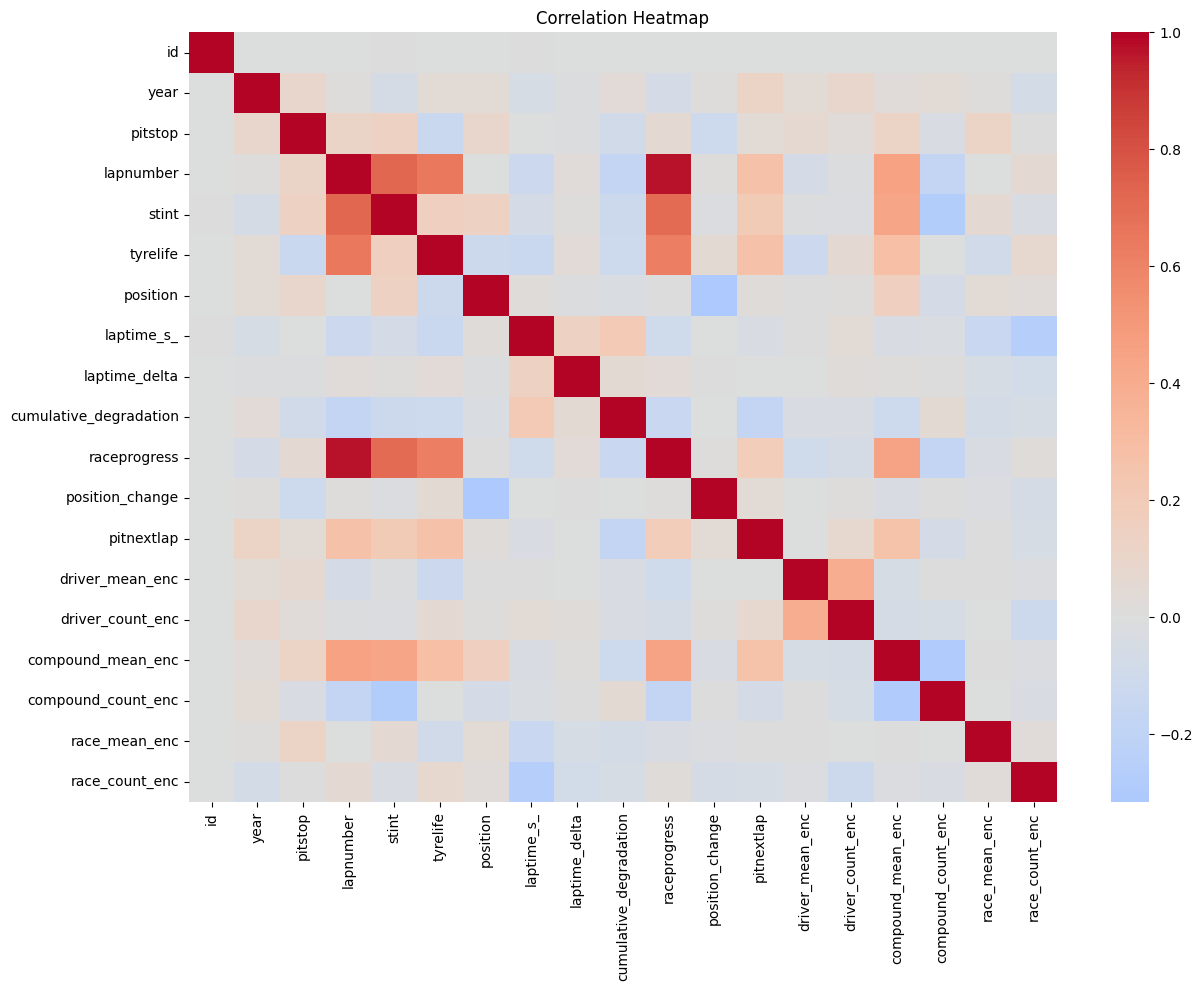

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# numerical columns only
corr_matrix = train.corr(numeric_only=True)

plt.figure(figsize=(14,10))

sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0
)

plt.title("Correlation Heatmap")

plt.show()

In [10]:
drop_cols = [
    'driver_count_enc',
    'compound_count_enc',
    'race_count_enc',
    'driver_mean_enc',
    'compound_mean_enc',
    'driver',
    'pitnextlap'
]

train_data = train_data.drop(
    columns=[c for c in drop_cols if c in train_data.columns]
)

test_df = test_df.drop(
    columns=[c for c in drop_cols if c in test_df.columns]
)

In [11]:
train['race_phase'] = pd.cut(
    train['lapnumber'],
    bins=[0,15,35,100],
    labels=['early','mid','late']
)

test['race_phase'] = pd.cut(
    test['lapnumber'],
    bins=[0,15,35,100],
    labels=['early','mid','late']
)

In [12]:
interaction_cols = [
    ('compound', 'race'),
    ('driver', 'compound'),
    ('race_phase', 'compound')
]

for c1, c2 in interaction_cols:

    train[f'{c1}_{c2}'] = (
        train[c1].astype(str)
        + "_"
        + train[c2].astype(str)
    )

    test[f'{c1}_{c2}'] = (
        test[c1].astype(str)
        + "_"
        + test[c2].astype(str)
    )

In [13]:
cat_cols = train.select_dtypes(
    include=['object', 'category']
).columns.tolist()
cat_cols


['driver',
 'compound',
 'race',
 'race_phase',
 'compound_race',
 'driver_compound',
 'race_phase_compound']

In [14]:

from sklearn.model_selection import train_test_split

X = train_data.drop("PitStop", axis=1)
y = train_data["PitStop"]


cat_cols = X.select_dtypes(
    include=['object']
).columns.tolist()

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)
cat_cols

['compound', 'race']

In [15]:
from catboost import CatBoostClassifier
model = CatBoostClassifier( task_type = 'GPU',verbose=0)
model.fit(X_train, y_train,cat_features=cat_cols)

CatBoostClassifier(task_type='GPU', verbose=0)

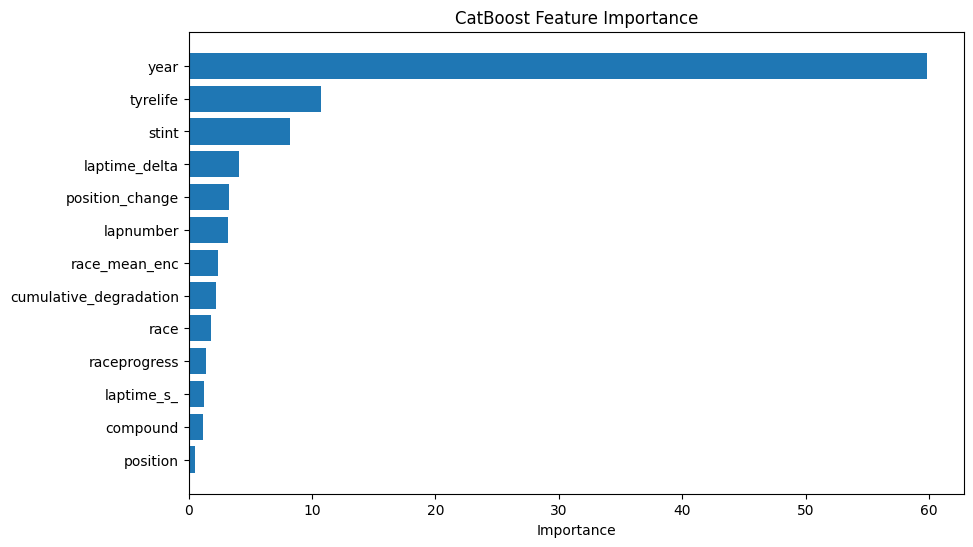

In [16]:
importance = model.get_feature_importance()

# Convert to 1D
importance = importance.flatten()

feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feat_imp = feat_imp.sort_values(
    by='Importance',
    ascending=False
)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.barh(feat_imp['Feature'], feat_imp['Importance'])

plt.gca().invert_yaxis()

plt.title("CatBoost Feature Importance")
plt.xlabel("Importance")

plt.show()

In [17]:
train_data.columns.tolist()

['compound',
 'race',
 'year',
 'PitStop',
 'lapnumber',
 'stint',
 'tyrelife',
 'position',
 'laptime_s_',
 'laptime_delta',
 'cumulative_degradation',
 'raceprogress',
 'position_change',
 'race_mean_enc']

In [18]:
print(train_data["PitStop"].value_counts(normalize = True))

PitStop
0    0.863882
1    0.136118
Name: proportion, dtype: float64


In [19]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from catboost import CatBoostClassifier
import numpy as np

X = train_data.drop("PitStop", axis=1)
y = train_data["PitStop"]

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = []

for train_idx, val_idx in skf.split(X, y):

    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]


    model = CatBoostClassifier(
        iterations=1000,
        learning_rate=0.05,
        depth=8,
        cat_features=cat_cols,
        task_type = 'GPU',
        eval_metric='F1',

        auto_class_weights='Balanced',

        random_seed=42,
        verbose=200
)

    model.fit(X_train, y_train)

    preds = model.predict(X_val)

    score = f1_score(y_val, preds)

    scores.append(score)

print("Mean F1:", np.mean(scores))

0:	learn: 0.7535523	total: 49.9ms	remaining: 49.8s
200:	learn: 0.8246534	total: 7.37s	remaining: 29.3s
400:	learn: 0.8380121	total: 14.6s	remaining: 21.8s
600:	learn: 0.8481092	total: 21.8s	remaining: 14.5s
800:	learn: 0.8550389	total: 29s	remaining: 7.21s
999:	learn: 0.8606803	total: 36.3s	remaining: 0us
0:	learn: 0.7499261	total: 35.8ms	remaining: 35.7s
200:	learn: 0.8246481	total: 7.36s	remaining: 29.3s
400:	learn: 0.8374227	total: 14.6s	remaining: 21.9s
600:	learn: 0.8465724	total: 21.9s	remaining: 14.5s
800:	learn: 0.8540617	total: 29.1s	remaining: 7.23s
999:	learn: 0.8603821	total: 36.3s	remaining: 0us
0:	learn: 0.7494136	total: 35.5ms	remaining: 35.5s
200:	learn: 0.8247111	total: 7.36s	remaining: 29.3s
400:	learn: 0.8377773	total: 14.6s	remaining: 21.8s
600:	learn: 0.8460282	total: 21.8s	remaining: 14.5s
800:	learn: 0.8529097	total: 29s	remaining: 7.21s
999:	learn: 0.8592522	total: 36.3s	remaining: 0us
0:	learn: 0.7501454	total: 36.9ms	remaining: 36.8s
200:	learn: 0.8242954	tota

In [20]:
test_df.columns

Index(['compound', 'race', 'year', 'PitStop', 'lapnumber', 'stint', 'tyrelife',
       'position', 'laptime_s_', 'laptime_delta', 'cumulative_degradation',
       'raceprogress', 'position_change', 'race_mean_enc'],
      dtype='object')

In [21]:
print(set(X.columns) - set(test_df.columns))

set()


In [22]:
test_df
test = test[X.columns]
probs = model.predict_proba(test)[:,1]

preds = (probs > 0.35).astype(int)

In [23]:
sample_submission = pd.read_csv(
    "/kaggle/input/competitions/playground-series-s6e5/sample_submission.csv"
)


In [24]:
submission = pd.DataFrame({
    "id": sample_submission["id"],
    "PitStop": preds
})
submission.to_csv("submission.csv", index=False)
print(submission.head())

       id  PitStop
0  439140        0
1  439141        0
2  439142        0
3  439143        1
4  439144        0
